# Chapter 9 — Small-World Network (Watts-Strogatz)
**Modeling Social Behavior** | Smaldino

--- 

This notebook translates `SmallWorldNetwork.nlogo` into Python.

The **small-world algorithm** (Watts & Strogatz, 1998) builds a network that
sits between the two extremes we have already modeled:

| Network | Clustering | Path length |
|---|---|---|
| Ring lattice | High | Long |
| Random (E-R) | Low | Short |
| **Small-world** | **High** | **Short** |

The algorithm: start with a ring lattice (high clustering), then randomly
rewire each edge with probability `p`. A small amount of rewiring dramatically
shortens average path lengths while barely touching clustering —
producing the small-world sweet spot.

This notebook also reproduces **Figure 9.9** from the book.

## 1. Imports

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## 2. Global Parameters

These match the two sliders in the NetLogo interface.

**Global variables:**
- `NUM_NODES`: number of agents (nodes). NetLogo slider: 20–500.
- `REWIRING_PROB`: probability `p` of rewiring each edge. NetLogo slider: 0–1.
- `DEGREE`: hardcoded to 4 in the NetLogo `wire-lattice` procedure.
  The comment says this can be changed for arbitrary degree,
  but the model asserts `k = 4` as its default.

In [2]:
# --- Global Parameters ---
NUM_NODES     = 100   # number of nodes; NetLogo slider: 20 to 500
REWIRING_PROB = 0.04  # rewiring probability p; NetLogo slider default: 0.04
DEGREE        = 4     # initial ring lattice degree; hardcoded in NetLogo as 4

SEED = 42  # for reproducibility

## 3. Building Blocks — Reusing the Ring Lattice

The small-world algorithm starts by building a ring lattice, then rewires it.
We reuse `make_ring_lattice()` from the ring network notebook
(defined here for self-containedness).

In [3]:
def make_ring_lattice(num_nodes, degree):
    """
    Build a ring lattice — the starting point for the small-world algorithm.

    Each node connects to its degree/2 nearest neighbors on each side.
    Translates `wire-lattice` from SmallWorldNetwork.nlogo.

    Parameters
    ----------
    num_nodes : int — number of nodes
    degree    : int — number of edges per node (must be even)

    Returns
    -------
    G : nx.Graph
    """
    if degree >= num_nodes:
        degree = num_nodes - 1

    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    for n in range(num_nodes):
        for k in range(1, degree // 2 + 1):
            G.add_edge(n, (n + k) % num_nodes)

    return G

## 4. Rewiring — The Heart of the Algorithm

### `rewire_network()` — translating `rewire-network` from NetLogo

**NetLogo `rewire-network` logic:**
```
ask links [
  if (random-float 1) < rewiring-probability [
    ask end1 [
      create-link-with one-of other turtles with [not link-neighbor? myself]
    ]
    die
  ]
]
```

For each existing edge (u, v), with probability `p`:
1. Pick a new target node from all nodes that `u` is **not already connected to**
   (and that is not `u` itself).
2. Create a new edge from `u` to that new node.
3. Destroy the original edge (u, v).

**Important detail:** only `end1` (node `u`) forms the new edge — not `end2`.
This means rewiring can slightly change the degree of individual nodes,
though average degree is preserved across the whole network.

**Why snapshot the edges first?**
We call `list(G.edges())` before the loop starts. If we iterated over a live
view of `G.edges()` while modifying the graph, we would get unpredictable
results as edges are added and removed mid-loop. The snapshot ensures each
original edge is considered exactly once — matching NetLogo's `ask links`
behaviour, which also captures the agentset at the moment it is called.

In [4]:
def rewire_network(G, rewiring_prob, seed=None):
    """
    Apply Watts-Strogatz rewiring to a network in-place.

    Translates `rewire-network` from SmallWorldNetwork.nlogo.
    For each edge (u, v), with probability `rewiring_prob`, the edge is
    destroyed and a new edge is formed from u to a randomly chosen
    non-neighbor.

    Parameters
    ----------
    G             : nx.Graph — modified in-place
    rewiring_prob : float    — probability of rewiring each edge, in [0, 1]
    seed          : int or None

    Returns
    -------
    G : nx.Graph — the same graph, now rewired
    """
    # Local variable: rng — seeded random number generator.
    rng = np.random.default_rng(seed)

    # Snapshot of all edges before the loop.
    # Critical: we must not iterate over a live edge set while modifying it.
    # NetLogo handles this automatically; we do it explicitly here.
    edges_snapshot = list(G.edges())

    # Iterate over every original edge.
    # NetLogo: `ask links [ if (random-float 1) < rewiring-probability [ ... ] ]`
    for (u, v) in edges_snapshot:

        # Guard: this edge may have already been removed in a previous iteration
        # (if it appeared as end2 of an edge that was rewired from a different u).
        if not G.has_edge(u, v):
            continue

        if rng.random() < rewiring_prob:

            # All valid targets for the new edge from u:
            # any node that is not u itself and not already a neighbor of u.
            # NetLogo: `one-of other turtles with [not link-neighbor? myself]`
            # Local variable: non_neighbors.
            non_neighbors = [
                n for n in G.nodes()
                if n != u and not G.has_edge(u, n)
            ]

            # Guard: if u is already connected to every other node, skip.
            if not non_neighbors:
                continue

            # Pick one non-neighbor at random, destroy the old edge,
            # create the new one.
            # NetLogo: `create-link-with ...` then `die`.
            new_v = rng.choice(non_neighbors)
            G.remove_edge(u, v)
            G.add_edge(u, new_v)

    return G

## 5. `setup()` — Putting It Together

In NetLogo, clicking `setup` calls:
`make-turtles` → `wire-lattice` → `rewire-network`.
Our `setup()` does the same.

In [5]:
def setup(num_nodes, degree, rewiring_prob, seed=None):
    """
    Build a small-world network from scratch.

    Mirrors the NetLogo `setup` procedure:
      1. make-turtles   → create nodes
      2. wire-lattice   → build ring lattice with fixed degree
      3. rewire-network → randomly rewire edges with probability p

    Parameters
    ----------
    num_nodes     : int
    degree        : int   — initial ring lattice degree (4 in NetLogo)
    rewiring_prob : float — rewiring probability p
    seed          : int or None

    Returns
    -------
    G : nx.Graph — the small-world network
    """
    G = make_ring_lattice(num_nodes, degree)  # steps 1 + 2
    rewire_network(G, rewiring_prob, seed)    # step 3
    return G


# Build the small-world network using our global parameters.
G = setup(NUM_NODES, DEGREE, REWIRING_PROB, seed=SEED)

# Quick verification.
# Use the largest connected component (LCC) for path length,
# since rewiring can sometimes create isolated fragments.
lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"Nodes           : {G.number_of_nodes()}")
print(f"Edges           : {G.number_of_edges()}")
print(f"Avg degree      : {np.mean([d for _, d in G.degree()]):.3f}")
print(f"Clustering C    : {nx.average_clustering(G):.4f}")
print(f"Path length L   : {nx.average_shortest_path_length(lcc):.4f}  (on LCC)")

Nodes           : 100
Edges           : 200
Avg degree      : 4.000
Clustering C    : 0.4447
Path length L   : 7.1604  (on LCC)


## 6. Visualization — Three Network Structures Side by Side

Figure 9.9 in the book shows networks at p = 0 (lattice), intermediate p,
and p = 1 (random). Here we visualize all three with a circular layout
so the ring structure is visible and the long-range rewired edges stand out.

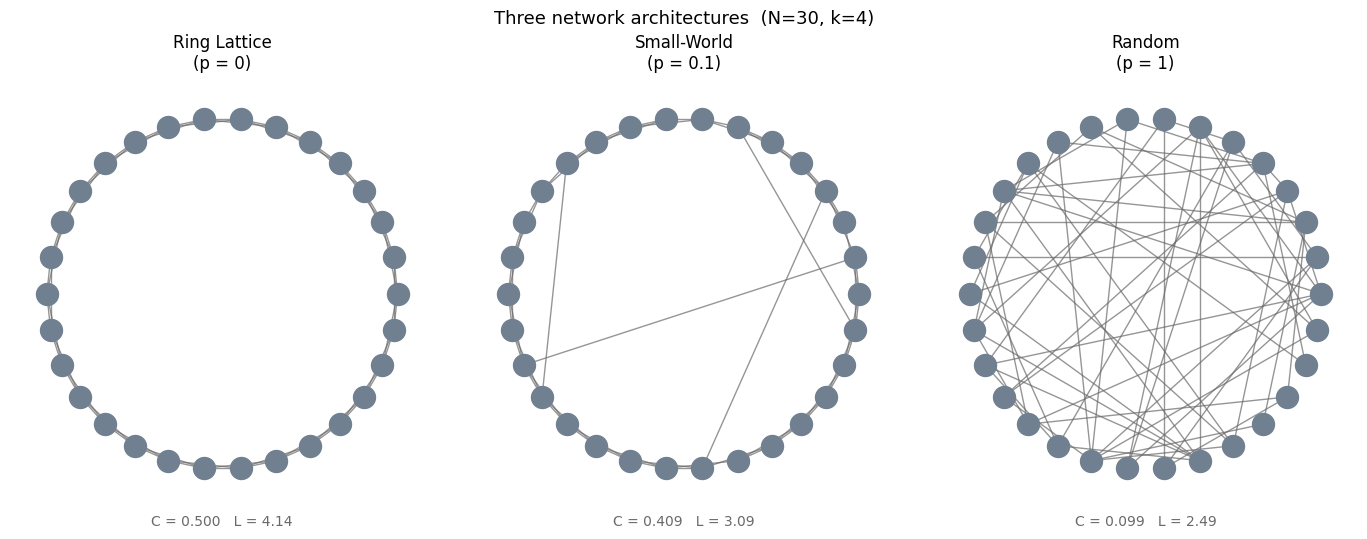

In [6]:
# Build three networks for visual comparison (small N for clarity).
N_vis = 30  # local variable

G_lattice    = setup(N_vis, DEGREE, rewiring_prob=0.0, seed=SEED)  # pure lattice
G_smallworld = setup(N_vis, DEGREE, rewiring_prob=0.1, seed=SEED)  # sweet spot
G_random     = setup(N_vis, DEGREE, rewiring_prob=1.0, seed=SEED)  # fully random

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
configs = [
    (G_lattice,    'Ring Lattice\n(p = 0)'),
    (G_smallworld, 'Small-World\n(p = 0.1)'),
    (G_random,     'Random\n(p = 1)'),
]

for ax, (net, title) in zip(axes, configs):
    # Circular layout so the ring origin is visible in all three.
    pos = nx.circular_layout(sorted(net.nodes()))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)

    nx.draw_networkx_edges(net, pos, edge_color='dimgray', width=1.0, alpha=0.7, ax=ax)
    nx.draw_networkx_nodes(net, pos, node_color='slategray', node_size=250, ax=ax)

    # Print C and L values under each panel.
    lcc_v = net.subgraph(max(nx.connected_components(net), key=len)).copy()
    C = nx.average_clustering(net)
    L = nx.average_shortest_path_length(lcc_v)
    ax.text(0.5, -0.05, f'C = {C:.3f}   L = {L:.2f}',
            transform=ax.transAxes, ha='center', fontsize=10, color='dimgray')

fig.suptitle(f'Three network architectures  (N={N_vis}, k={DEGREE})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Reproducing Figure 9.9 — C and L vs. Rewiring Probability

This is the central result of the small-world chapter.

Both C and L are **normalized** by their values at p = 0 (the pure lattice),
so both start at 1.0. We then track how quickly each falls as p increases.

The key finding: **path length drops much faster than clustering**.
This creates a wide range of intermediate p values where the network
still has high clustering but already has short path lengths —
the small-world regime.

We average over multiple runs to smooth stochastic variation, matching
the approach in Figure 9.9 (which uses 20 runs per p value).

In [7]:
def safe_path_length(G):
    """
    Average path length on the largest connected component.

    Path length is undefined between disconnected nodes, so we restrict
    the calculation to the LCC.

    Local variable: lcc — largest connected component subgraph.
    """
    lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return nx.average_shortest_path_length(lcc)


# --- Sweep parameters ---
# Local variables: N_fig, n_runs, p_values_log, p_values_all.
N_fig  = 500   # matches the BehaviorSpace experiments in the NetLogo file
n_runs = 10    # replicate runs per p value (book uses 20; 10 runs is faster)

# Log-spaced p values from 0.001 to 1.0.
# Log spacing is appropriate here because the interesting dynamics happen
# at very small p (see the x-axis of Figure 9.9 which is on a log scale).
p_values_log = np.logspace(-3, 0, 20)
p_values_all = np.concatenate([[0], p_values_log])

# Compute baseline values at p = 0 for normalization.
G_baseline = make_ring_lattice(N_fig, DEGREE)
C0 = nx.average_clustering(G_baseline)
L0 = safe_path_length(G_baseline)
print(f"Baseline lattice (p=0):  C = {C0:.4f},  L = {L0:.4f}")

# Sweep.
mean_C_norm = [1.0]  # p=0 starts at 1.0 by definition
mean_L_norm = [1.0]

for p in p_values_log:
    run_C, run_L = [], []
    for run in range(n_runs):
        G = setup(N_fig, DEGREE, rewiring_prob=p, seed=run)
        run_C.append(nx.average_clustering(G))
        run_L.append(safe_path_length(G))
    mean_C_norm.append(np.mean(run_C) / C0)
    mean_L_norm.append(np.mean(run_L) / L0)

print("Sweep complete.")

Baseline lattice (p=0):  C = 0.5000,  L = 62.8758
Sweep complete.


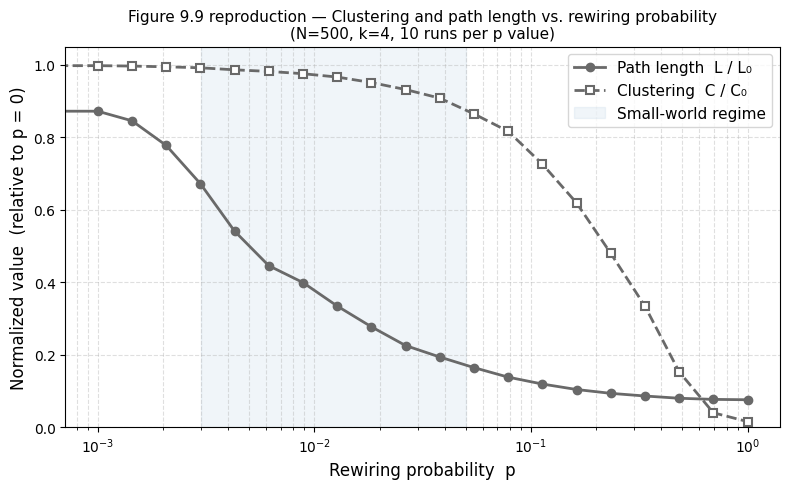


Key takeaway:
  Path length (circles) collapses at very small p.
  Clustering (squares) stays near 1.0 until much larger p.
  The blue band is the small-world regime: short paths + high clustering.


In [8]:
# --- Plot Figure 9.9 ---
fig, ax = plt.subplots(figsize=(8, 5))

# Path length: filled circles (matches Figure 9.9 style).
ax.plot(p_values_all, mean_L_norm, 'o-',
        color='dimgray', markersize=6, lw=2,
        label='Path length  L / L\u2080')

# Clustering: open squares.
ax.plot(p_values_all, mean_C_norm, 's--',
        color='dimgray', markersize=6, lw=2,
        markerfacecolor='white', markeredgewidth=1.5,
        label='Clustering  C / C\u2080')

# Shade the small-world regime.
ax.axvspan(0.003, 0.05, alpha=0.08, color='steelblue',
           label='Small-world regime')

ax.set_xscale('log')
ax.set_xlabel('Rewiring probability  p', fontsize=12)
ax.set_ylabel('Normalized value  (relative to p = 0)', fontsize=12)
ax.set_title(
    f'Figure 9.9 reproduction — Clustering and path length vs. rewiring probability\n'
    f'(N={N_fig}, k={DEGREE}, {n_runs} runs per p value)',
    fontsize=11
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nKey takeaway:")
print("  Path length (circles) collapses at very small p.")
print("  Clustering (squares) stays near 1.0 until much larger p.")
print("  The blue band is the small-world regime: short paths + high clustering.")

## 8. NetworkX Shortcut — `watts_strogatz_graph()`

NetworkX has a built-in Watts-Strogatz generator. It uses a slightly
different rewiring convention (always rewires the clockwise edge from each
node in order) but produces statistically equivalent networks.
Good to know it exists for production use.

In [9]:
# NetworkX built-in Watts-Strogatz generator.
# Arguments: n nodes, k initial degree, p rewiring probability.
G_nx = nx.watts_strogatz_graph(n=NUM_NODES, k=DEGREE, p=REWIRING_PROB, seed=SEED)

lcc_nx = G_nx.subgraph(max(nx.connected_components(G_nx), key=len)).copy()
print("Using nx.watts_strogatz_graph():")
print(f"  Nodes       : {G_nx.number_of_nodes()}")
print(f"  Edges       : {G_nx.number_of_edges()}")
print(f"  Clustering  : {nx.average_clustering(G_nx):.4f}")
print(f"  Path length : {nx.average_shortest_path_length(lcc_nx):.4f}")

Using nx.watts_strogatz_graph():
  Nodes       : 100
  Edges       : 200
  Clustering  : 0.4720
  Path length : 8.0800


## 9. Summary — All Three Network Types Compared

A clean side-by-side comparison with matched N and average degree,
confirming that the small-world network achieves both short paths
and high clustering.

In [10]:
def make_random_network(num_nodes, wiring_prob, seed=None):
    """G(n,p) random network (from ch9_random_network.ipynb)."""
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if rng.random() < wiring_prob:
                G.add_edge(i, j)
    return G


# Matched parameters: N=100 nodes, target average degree = 4.
N_cmp = 100
K_cmp = 4
p_er  = K_cmp / (N_cmp - 1)   # wiring prob that gives E[k] = 4 for G(n,p)

G_lat = make_ring_lattice(N_cmp, K_cmp)
G_sw  = setup(N_cmp, K_cmp, rewiring_prob=0.05, seed=SEED)
G_rnd = make_random_network(N_cmp, p_er, seed=SEED)

print(f"{'Network':<24} {'<k>':>5} {'C':>8} {'L':>8}")
print("-" * 47)
for label, net in [
    ("Ring Lattice", G_lat),
    ("Small-World  (p=0.05)", G_sw),
    (f"Random       (p={p_er:.4f})", G_rnd),
]:
    avg_k = np.mean([d for _, d in net.degree()])
    C     = nx.average_clustering(net)
    L     = safe_path_length(net)
    print(f"{label:<24} {avg_k:>5.2f} {C:>8.4f} {L:>8.4f}")

print()
print("The small-world network achieves both high C and short L.")
print("The ring lattice has high C but long L.")
print("The random network has short L but low C.")

Network                    <k>        C        L
-----------------------------------------------
Ring Lattice              4.00   0.5000  12.8788
Small-World  (p=0.05)     4.00   0.4330   6.3160
Random       (p=0.0404)   3.84   0.0290   3.5155

The small-world network achieves both high C and short L.
The ring lattice has high C but long L.
The random network has short L but low C.
